# 📘 Waveform Design Theory

This notebook covers key concepts and simulations of waveform design for sonar/DSP applications.

## 🔹 1. What is Waveform Design?
Waveform design is the process of crafting a signal to optimize detection, resolution, or communication under constraints like bandwidth, power, or Doppler shift.

## 🔹 2. Linear Frequency Modulated (LFM) Chirp
An LFM chirp has a frequency that linearly sweeps from $f_0$ to $f_1$ over time.

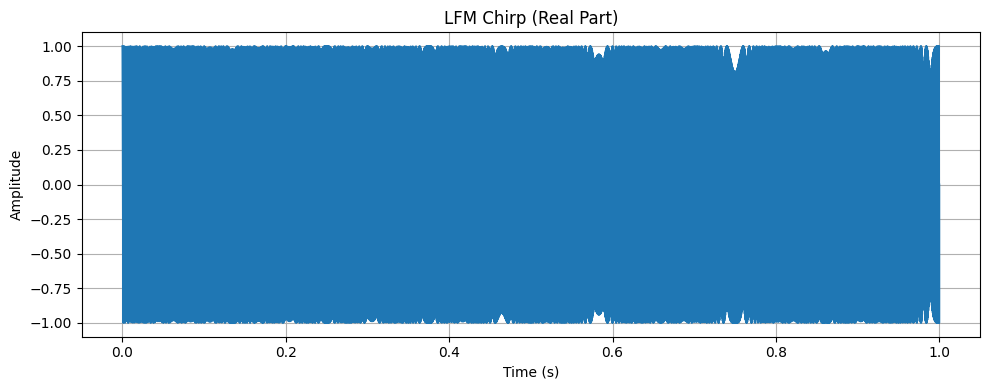

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
fs = 10000  # Sampling rate
T = 1       # Duration (s)
t = np.linspace(0, T, int(fs*T), endpoint=False)
f0, f1 = 500, 2500

# Generate chirp
k = (f1 - f0) / T
phase = 2 * np.pi * (f0 * t + 0.5 * k * t**2)
chirp_signal = np.exp(1j * phase)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, chirp_signal.real)
plt.title("LFM Chirp (Real Part)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔹 3. Time-Frequency Representation (Spectrogram)
See how the frequency changes over time.

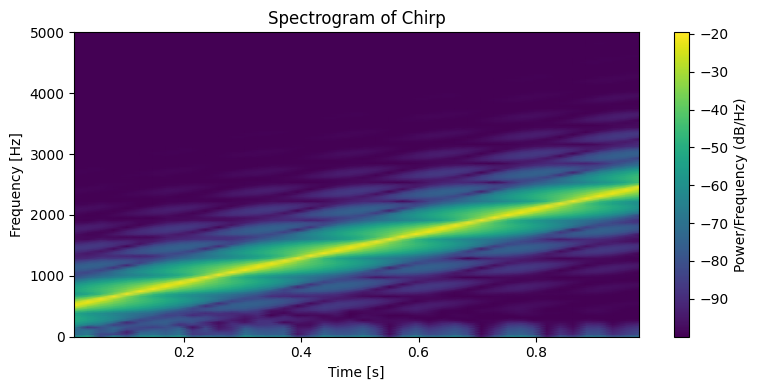

In [2]:
from scipy.signal import spectrogram

f, t_spec, Sxx = spectrogram(chirp_signal.real, fs=fs)
plt.figure(figsize=(8, 4))
plt.pcolormesh(t_spec, f, 10*np.log10(Sxx + 1e-10), shading='gouraud')
plt.title("Spectrogram of Chirp")
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [s]")
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.tight_layout()
plt.show()

## 🔹 4. Ambiguity Function
Measures resolution in time-delay and Doppler shift.

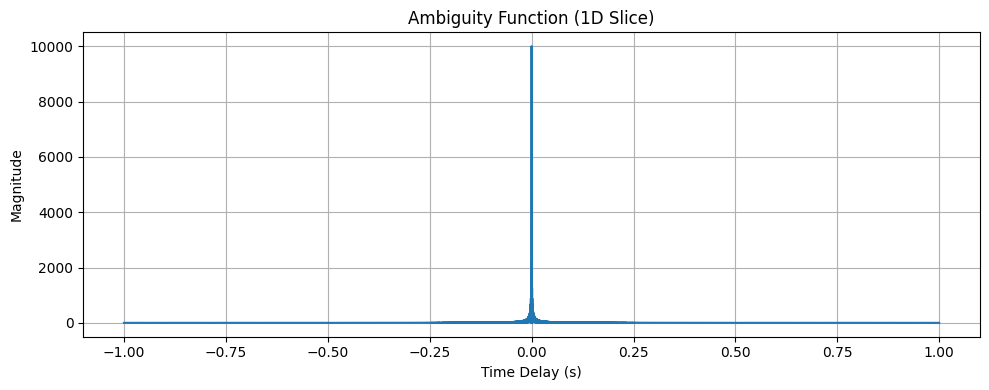

In [3]:
from scipy.signal import correlate

def ambiguity_func(s, fs):
    N = len(s)
    tau = np.arange(-N+1, N) / fs
    amb = correlate(s, s, mode='full')
    return tau, amb

tau, amb = ambiguity_func(chirp_signal, fs)
plt.figure(figsize=(10, 4))
plt.plot(tau, np.abs(amb))
plt.title("Ambiguity Function (1D Slice)")
plt.xlabel("Time Delay (s)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## ✅ Summary
- LFM chirps offer good resolution and robustness.
- Spectrogram reveals how frequency evolves.
- Ambiguity function assesses time-frequency localization.

Next steps: implement Barker codes and matched filtering.